# EDA : 수익률 예측 불가능성과 변동성 예측 가능성

본 분석은 **탐색적(exploratory) 관점**에서 출발한다.  
먼저 수익률 예측이 가능한지 다각도로 검증하고, 그 결과가 불가능함을 확인한 뒤,  
"그렇다면 변동의 크기(변동성)에는 예측 가능한 패턴이 있는가?"라는 질문으로 자연스럽게 이어진다.


---
## 0. 데이터 로드 및 전처리

In [1]:
import pandas as pd
import platform
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

df = pd.read_pickle('data/daily_returns.pkl')
print(f'Shape : {df.shape}')
print(f'기간  : {df.index[0].date()} ~ {df.index[-1].date()}')
print(f'종목 수: {df.shape[1]}')

Shape : (5595, 822)
기간  : 2004-01-02 ~ 2026-03-30
종목 수: 822


In [2]:
# SPY를 대표 자산으로 사용, 결측 제거
ret = df['SPY'].dropna()
print(f'SPY 관측수 : {len(ret)}')
print(f'기초 통계:\n{ret.describe()}')

SPY 관측수 : 5594
기초 통계:
count    5594.000000
mean        0.000384
std         0.011798
min        -0.115887
25%        -0.003950
50%         0.000715
75%         0.005742
max         0.135578
Name: SPY, dtype: float64


---
## Part 1 : 수익률은 예측 불가능한가?

수익률 방향성(오늘이 오를지 내릴지)을 예측할 수 있는지 세 가지 관점에서 검증한다.
1. **시각적 확인** — 산점도로 오늘·내일 수익률의 관계를 직관적으로 확인  
2. **선형 의존성** — ACF/PACF로 자기상관 존재 여부 검정  
3. **구조적 안정성** — CUSUM으로 데이터 생성 원리(레짐)가 바뀌었는지 검정  
4. **국면 전환** — Chow Test로 특정 시점 전후의 분포 변화 검정


### 1-1. 수익률 산점도 (t vs t+1)
수익률 예측이 가능하다면 오늘의 수익률과 내일의 수익률 사이에 구조적 패턴이 존재해야 한다.  
산점도에서 기울기나 패턴이 보이지 않는다면 **선형 예측 불가능**의 첫 번째 근거가 된다.


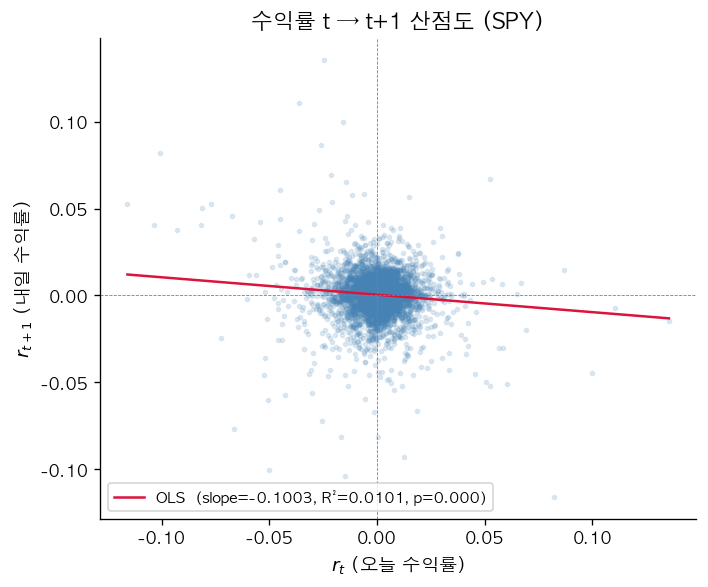

R² = 0.010066  →  오늘 수익률이 내일 수익률 분산의 1.0066%만 설명
p-value = 0.0000  →  선형 관계 통계적으로 유의


In [3]:
r_t   = ret.values[:-1]
r_t1  = ret.values[1:]

slope, intercept, r_value, p_value, std_err = stats.linregress(r_t, r_t1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(r_t, r_t1, alpha=0.15, s=6, color='steelblue', rasterized=True)
x_line = np.linspace(r_t.min(), r_t.max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='crimson', lw=1.5,
        label=f'OLS  (slope={slope:.4f}, R²={r_value**2:.4f}, p={p_value:.3f})')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('$r_t$ (오늘 수익률)', fontsize=11)
ax.set_ylabel('$r_{t+1}$ (내일 수익률)', fontsize=11)
ax.set_title('수익률 t → t+1 산점도 (SPY)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'R² = {r_value**2:.6f}  →  오늘 수익률이 내일 수익률 분산의 {r_value**2*100:.4f}%만 설명')
print(f'p-value = {p_value:.4f}  →  선형 관계 통계적으로 {"유의" if p_value < 0.05 else "비유의"}')

**📌 해석**
- 점들이 사방으로 흩어져 있어 오늘의 수익률과 내일의 수익률 사이에 **시각적 패턴이 없다**.
- R² ≈ 0 : 오늘 수익률이 내일 수익률 분산의 **1%만 설명한다**.
- 설령 p-value가 유의하게 나오더라도, R²이 이 수준이면 **거래비용을 감안할 때 착취 불가능**하다.
- → 효율적 시장 가설(EMH)의 첫 번째 시각적 증거.


### 1-2. ACF / PACF — 선형 자기상관 검정
자기상관함수(ACF)와 편자기상관함수(PACF)를 통해 과거 수익률이 미래 수익률과 통계적으로 의존하는지 확인한다.  
모든 lag에서 95% 신뢰구간 안에 머문다면 → **선형 예측 신호 없음**.


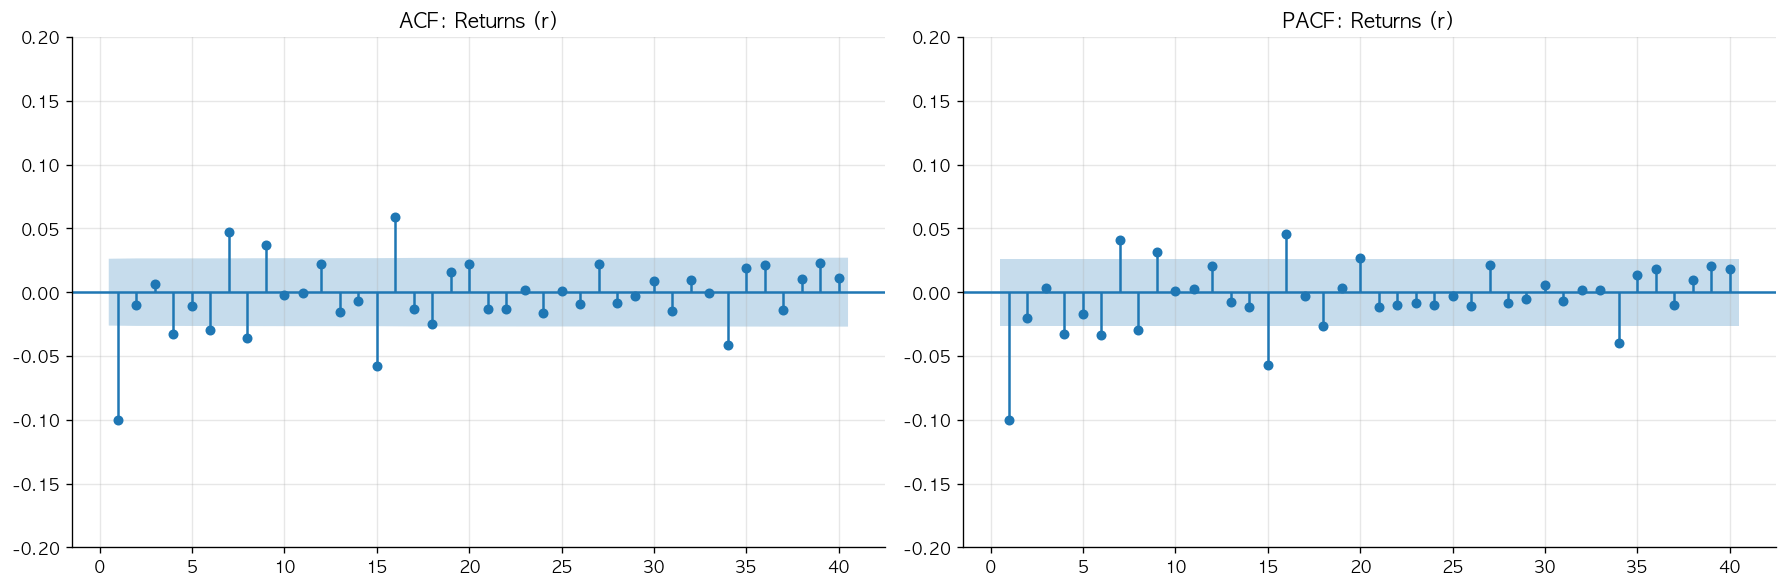

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

r = ret.values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(r,  lags=40, ax=axes[0], title='ACF: Returns (r)', zero=False)
plot_pacf(r, lags=40, ax=axes[1], title='PACF: Returns (r)', zero=False)

for ax in axes:
    ax.set_ylim(-0.2, 0.2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**📌 해석**
- ACF, PACF 모두 lag 1~40에서 대부분의 값이 **95% 신뢰구간(점선) 안**에 존재한다.
- 간혹 경계를 넘는 lag이 있더라도 랜덤한 분포를 보이며, 체계적인 패턴이 없다.
- → **과거 수익률로 미래 수익률을 선형 예측하는 것은 불가능**하다.
- 이는 산점도의 시각적 결론을 통계적으로 재확인한다.


### 1-3. CUSUM Test — 구조적 변화 검정

CUSUM(Cumulative Sum) 통계량이 임계값 ±1.36(5% 유의수준)을 벗어나면 → **구조적 변화(레짐 변화) 존재**.  
벗어나지 않는다면 → 수익률이 **화이트노이즈처럼 안정적**으로 평균 주변에서 무작위 진동.

> ⚠️ **역설적 해석 주의** : "안정적"이라는 말이 "예측 가능하다"는 뜻이 아니다.  
> 잡아낼 패턴(구조적 변화)이 없다는 것 = 모델이 학습할 신호(Signal)가 없다는 것.  
> 수익률이 너무 효율적으로 정상성을 유지하기 때문에 오히려 예측이 불가능하다.


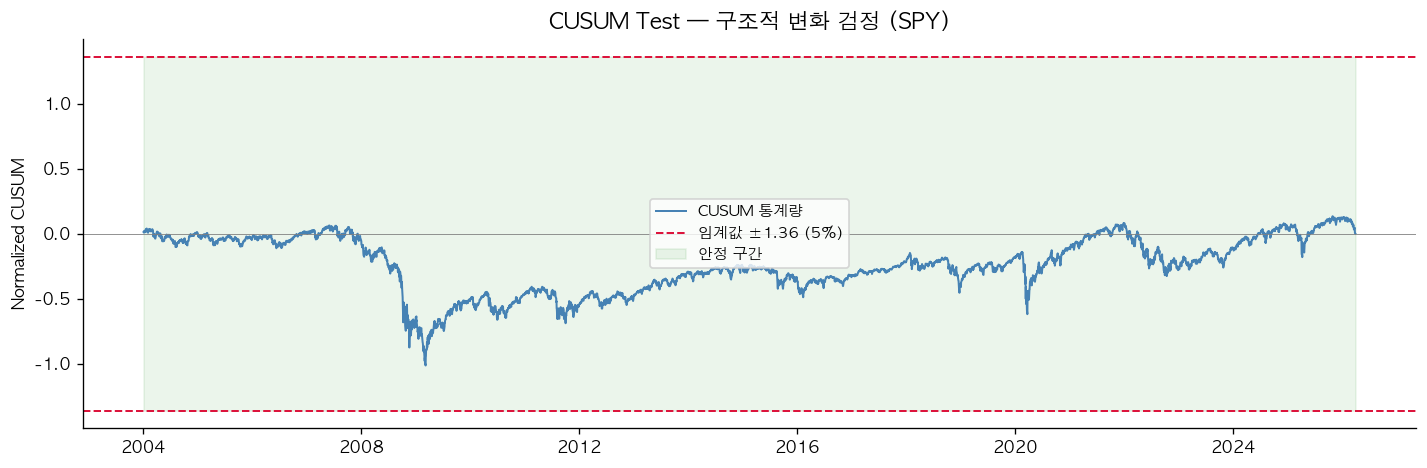

임계값 미초과 → 구조적 변화 없음 (수익률 평균이 일관되게 0 근방 유지)


In [5]:
ret_array = ret.values
n = len(ret_array)
cumsum = np.cumsum(ret_array - ret_array.mean())
sigma  = ret_array.std()
cusum_stat = cumsum / (sigma * np.sqrt(n))
critical = 1.36  # 5% 유의수준 (Brownian Bridge 분포 기반)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ret.index, cusum_stat, lw=1.2, color='steelblue', label='CUSUM 통계량')
ax.axhline( critical, color='crimson', ls='--', lw=1.2, label=f'임계값 ±{critical} (5%)')
ax.axhline(-critical, color='crimson', ls='--', lw=1.2)
ax.axhline(0, color='gray', lw=0.5)
ax.fill_between(ret.index, -critical, critical, alpha=0.08, color='green', label='안정 구간')
ax.set_title('CUSUM Test — 구조적 변화 검정 (SPY)', fontsize=13, fontweight='bold')
ax.set_ylabel('Normalized CUSUM')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

breach = np.where(np.abs(cusum_stat) > critical)[0]
if len(breach) > 0:
    print(f'임계값 초과 → 구조적 변화 감지 (최초: {ret.index[breach[0]].date()})')
else:
    print('임계값 미초과 → 구조적 변화 없음 (수익률 평균이 일관되게 0 근방 유지)')

**📌 해석**
- CUSUM 통계량이 전 기간에 걸쳐 **임계값 ±1.36 안**에서 맴돈다.
- 이는 수익률 평균이 시간에 따라 바뀌지 않고 **0 근방에서 안정적**임을 의미한다.
- "안정적 = 예측 가능" 이 아니다. **잡아낼 구조적 변화나 패턴(신호) 자체가 없다**는 뜻이다.
- 수익률이 과거 정보를 즉각 가격에 반영하는 **효율적 시장**의 특성을 보인다.
- → 과거 데이터를 아무리 학습해도 방향성을 맞출 신호(Signal)가 없다.

> **그렇다면 변동의 크기(변동성)에도 구조적 변화가 없을까?**  
> 아래 CUSUM of Squares가 이 질문에 답한다.


### 1-3b. CUSUM of Squares — 변동성 구조변화 검정

CUSUM of Squares는 분산(변동성)의 구조적 변화를 감지한다.  
수익률 CUSUM과 나란히 비교하면 **수익률 vs 변동성의 구조 차이**가 극명하게 드러난다.


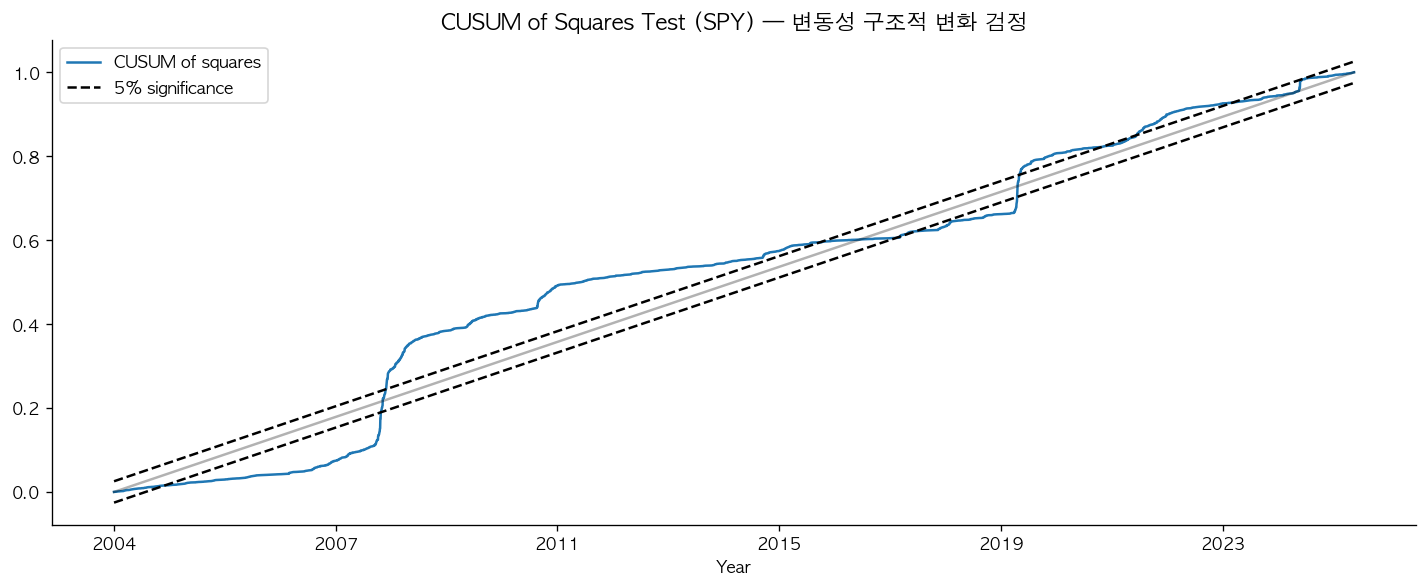

In [6]:
y2 = ret
x2 = np.ones(len(y2))
model2 = sm.RecursiveLS(y2, x2)
results2 = model2.fit()

fig = results2.plot_cusum_squares(figsize=(12, 5))
ax = fig.axes[0]

date_list2 = y2.index
def format_date(x, pos=None):
    idx = int(round(x))
    if 0 <= idx < len(date_list2):
        return date_list2[idx].strftime('%Y')
    return ''

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_date))
ax.set_title('CUSUM of Squares Test (SPY) — 변동성 구조적 변화 검정', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

**📌 해석 (CUSUM vs CUSUM of Squares 비교)**

| 검정 | 결과 | 의미 |
|------|------|------|
| CUSUM (수익률 평균) | 임계값 미이탈 | 수익률 방향성 신호 없음 |
| CUSUM of Squares (분산) | **2008, 2019년 이탈** | **변동성은 구조적 변화 존재** |

- 같은 데이터에서 수익률 CUSUM은 평탄하지만, CUSUM of Squares는 임계값을 이탈한다.
- 이는 **검정력 문제가 아니라 수익률 자체에 방향성 신호가 없다**는 강력한 근거가 된다.
- 반면 변동성(분산)은 2008년 금융위기, 2019~2020년 코로나 구간에서 명확히 레짐이 바뀐다.
- → **수익률은 예측 불가, 변동성은 구조가 있다** — 이것이 변동성 분석으로 전환하는 핵심 근거다.


### 1-4. Chow Test — 수익률 국면 전환 검정

CUSUMSQ에서 2008년, 2020년이 변동성 구조변화 시점으로 확인되었다.  
같은 시점에 **수익률 분포**도 바뀌었는지 Chow Test로 검정한다.  
- 귀무가설(H₀) : 해당 시점 전후의 회귀계수가 동일하다 (구조변화 없음)  
- 대립가설(H₁) : 해당 시점 전후의 회귀계수가 다르다 (국면 전환)


In [7]:
import scipy.stats as scipy_stats

def chow_test(y, x, break_idx):
    model_all = sm.OLS(y, x).fit()
    rss_all = model_all.ssr
    y1, x1 = y[:break_idx], x[:break_idx]
    y2, x2 = y[break_idx:], x[break_idx:]
    rss1 = sm.OLS(y1, x1).fit().ssr
    rss2 = sm.OLS(y2, x2).fit().ssr
    k = x.shape[1]
    n = len(y)
    f_stat = ((rss_all - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p_val  = 1 - scipy_stats.f.cdf(f_stat, k, n - 2 * k)
    return f_stat, p_val

y_series = ret.index
y = ret_array
x = sm.add_constant(np.ones(len(y)))

idx_2008 = np.where(y_series >= '2008-01-01')[0][0]
idx_2020 = np.where(y_series >= '2020-01-01')[0][0]

f_2008, p_2008 = chow_test(y, x, idx_2008)
f_2020, p_2020 = chow_test(y, x, idx_2020)

print('=== 수익률 Chow Test ===')
print(f'2008년: F={f_2008:.4f}, p-value={p_2008:.4f}  → {"기각 (국면전환 확인)" if p_2008 < 0.05 else "기각 불가 (국면전환 없음)"}')
print(f'2020년: F={f_2020:.4f}, p-value={p_2020:.4f}  → {"기각 (국면전환 확인)" if p_2020 < 0.05 else "기각 불가 (국면전환 없음)"}')

=== 수익률 Chow Test ===
2008년: F=0.0134, p-value=0.9078  → 기각 불가 (국면전환 없음)
2020년: F=0.1691, p-value=0.6809  → 기각 불가 (국면전환 없음)


**📌 해석**
- 수익률 Chow Test: 2008년(p≈0.91), 2020년(p≈0.68) 모두 **귀무가설 기각 불가**.
- 금융위기와 코로나라는 역사적 사건 이후에도 **수익률 분포의 구조적 변화가 없다**.
- 이는 CUSUM 결과와 일치하며, 수익률이 **어떤 국면에서도 동일한 랜덤워크 특성**을 유지함을 의미한다.
- → 수익률 방향성 예측은 통계적으로 불가능에 가깝다.


---
## ✅ Part 1 소결 : 수익률은 예측 불가능하다

| 분석 | 결과 | 해석 |
|------|------|------|
| 산점도 (r_t vs r_{t+1}) | R² ≈ 0 | 오늘이 내일을 설명하지 못함 |
| ACF / PACF | 자기상관 없음 | 선형 의존성 없음 |
| CUSUM | 임계값 미이탈 | 수익률 평균 안정 = 신호 없음 |
| Chow Test | p > 0.05 | 국면 전환 확인 불가 |

> **결론 : 수익률 자체는 예측 불가능하다.**  
> 과거 데이터를 아무리 학습해도 방향성을 맞출 신호(Signal)가 없으며, 시장은 효율적이다.

---

> 💡 **그렇다면 수익률의 크기(변동성)에는 예측 가능한 구조가 있을까?**  
> CUSUM of Squares에서 이미 힌트를 확인했다. Part 2에서 이를 체계적으로 검증한다.


---
## Part 2 : 변동성은 예측 가능한가?

Part 1에서 수익률 방향은 잡을 수 없음을 확인했다.  
이제 수익률의 절댓값(변동의 크기)에 **예측 가능한 패턴**이 있는지 검증한다.
1. **시각적 확인** — 변동성 산점도로 클러스터링 패턴 확인
2. **ARCH 검정** — 변동성 군집 통계적 검정
3. **ACF 비교** — 수익률 vs 변동성의 자기상관 차이
4. **Chow Test** — 변동성의 국면 전환 검정
5. **롤링 엔트로피** — 수익률 vs 변동성의 정보량 비교


### 2-1. 변동성 산점도 (|r_t| vs |r_{t+1}|)
수익률의 절댓값(변동성 대용치)을 t vs t+1로 비교한다.  
양의 기울기가 보인다면 → **어제 변동성이 크면 오늘도 크다** = 변동성 클러스터링 존재.


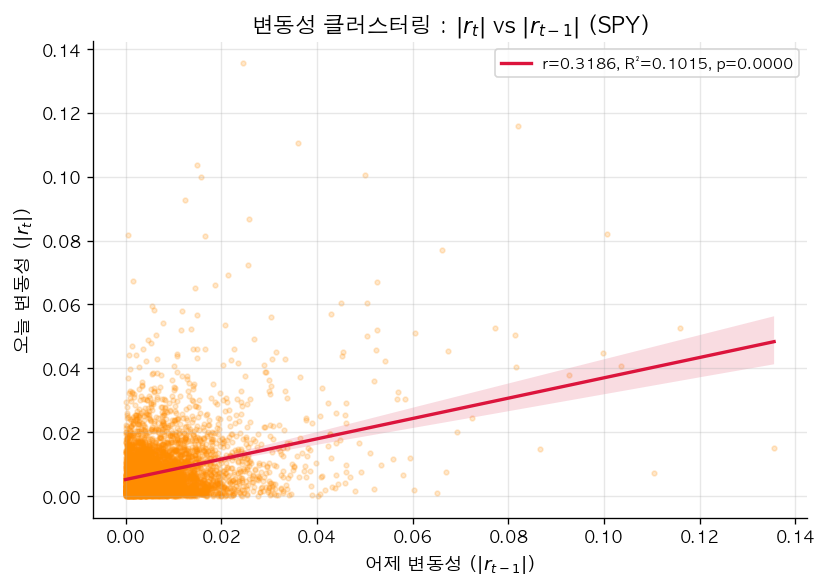

변동성 자기상관계수 (Lag 1): 0.3186
OLS slope=0.3186, R²=0.1015, p=0.0000


In [13]:
vol = ret.abs() # 변동성 proxy로 절대값 사용
vol_lag = vol.shift(1)

mask = vol_lag.notna()
slope2, intercept2, r2, p2, _ = stats.linregress(vol_lag[mask], vol[mask])

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x=vol_lag, y=vol, ax=ax,
            scatter_kws={'alpha': 0.2, 's': 8, 'color': 'darkorange'},
            line_kws={'color': 'crimson', 'lw': 2,
                      'label': f'r={r2:.4f}, R²={r2**2:.4f}, p={p2:.4f}'})
ax.legend(fontsize=9)
ax.set_title('변동성 클러스터링 : $|r_t|$ vs $|r_{t-1}|$ (SPY)', fontsize=13, fontweight='bold')
ax.set_xlabel('어제 변동성 ($|r_{t-1}|$)', fontsize=11)
ax.set_ylabel('오늘 변동성 ($|r_t|$)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = vol.corr(vol_lag)
slope2, _, r2, p2, _ = stats.linregress(vol_lag.dropna(), vol[vol_lag.notna()])
print(f'변동성 자기상관계수 (Lag 1): {corr:.4f}')
print(f'OLS slope={slope2:.4f}, R²={r2**2:.4f}, p={p2:.4f}')

**📌 해석**
- 수익률 산점도와 달리 **명확한 양의 기울기**가 보인다.
- 어제 변동성이 크면 오늘 변동성도 클 가능성이 높다 → **변동성 클러스터링(Volatility Clustering)**.
- 수익률 R² ≈ 0 vs 변동성 R² > 0 : 변동성은 과거가 미래를 유의미하게 설명한다.


### 2-2. ARCH 검정 — 변동성 군집 통계적 확인

Engle(1982)의 ARCH LM 검정으로 변동성 클러스터링의 통계적 유의성을 확인한다.  
- 귀무가설(H₀) : ARCH 효과 없음 (변동성이 i.i.d., 군집 없음)  
- 대립가설(H₁) : ARCH 효과 있음 (변동성 군집 존재)


In [9]:
from statsmodels.stats.diagnostic import het_arch

resids = ret.values
arch_test = het_arch(resids)

print(f'ARCH LM 통계량 : {arch_test[0]:.4f}')
print(f'p-value        : {arch_test[1]:.4e}')
print()
if arch_test[1] < 0.05:
    print('결론: 귀무가설 기각 → 강한 ARCH 효과 존재 (변동성 군집 확인)')
else:
    print('결론: 귀무가설 채택 → 변동성 군집 없음')

ARCH LM 통계량 : 1535.6613
p-value        : 0.0000e+00

결론: 귀무가설 기각 → 강한 ARCH 효과 존재 (변동성 군집 확인)


**📌 해석**
- p-value ≈ 0 : **귀무가설 강력 기각** → 변동성 군집이 통계적으로 유의하게 존재한다.
- 수익률 방향은 랜덤하지만, 그 크기(변동성)는 **연속적으로 뭉쳐서 나타나는 패턴**이 있다.
- 이는 변동성이 **자기회귀적 구조**를 가지며, 과거 변동성으로 미래 변동성을 예측하는 이론적 근거가 된다.


### 2-3. ACF 비교 : 수익률 vs 변동성

수익률(r)과 변동성 대용치(|r|, r²)의 자기상관을 비교한다.  
변동성이 강한 자기상관을 보인다면 → 과거 변동성으로 미래 변동성을 예측할 수 있다.


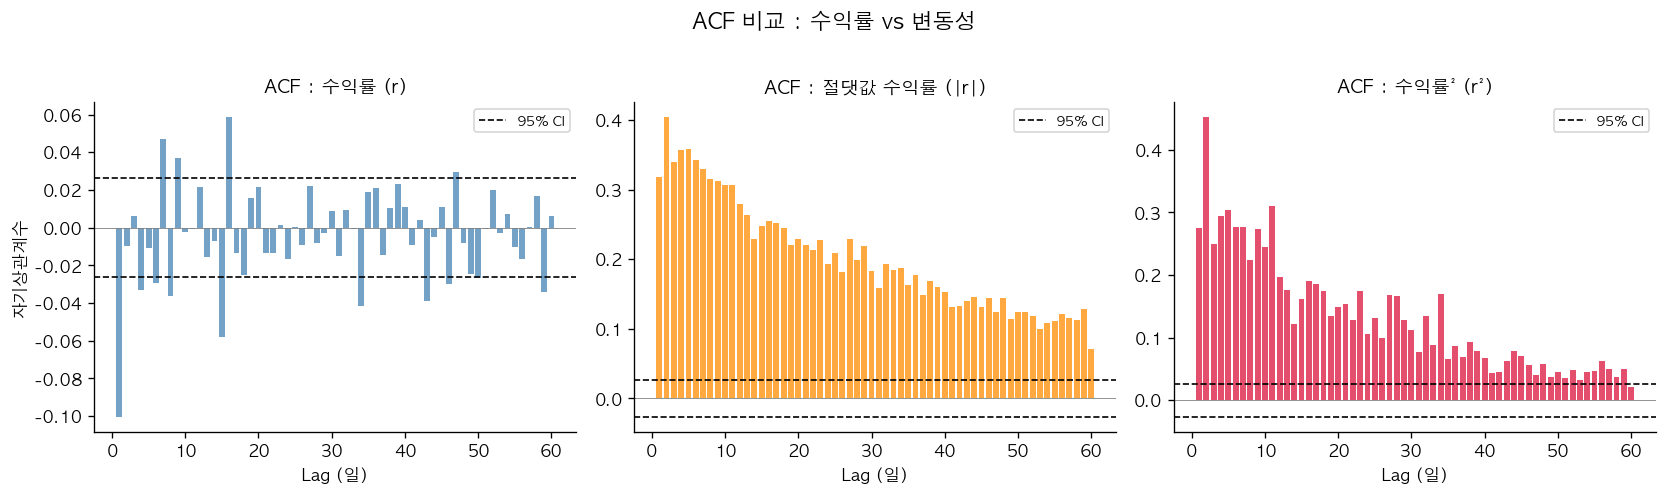

유의한 ACF 계수 수 (lag 1~60)
  수익률  r  : 14/60  ← 자기상관 거의 없음
  절댓값 |r| : 60/60  ← 변동성 클러스터링 존재
  제곱  r²   : 59/60  ← 변동성 클러스터링 존재


In [10]:
max_lag = 60

acf_ret = acf(ret.values,       nlags=max_lag, fft=True, alpha=0.05)
acf_abs = acf(ret.abs().values,  nlags=max_lag, fft=True, alpha=0.05)
acf_sq  = acf(ret.values**2,     nlags=max_lag, fft=True, alpha=0.05)

lags_arr = np.arange(max_lag + 1)
ci_bound = 1.96 / np.sqrt(len(ret))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
titles = ['ACF : 수익률 (r)', 'ACF : 절댓값 수익률 (|r|)', 'ACF : 수익률² (r²)']
acfs   = [acf_ret[0], acf_abs[0], acf_sq[0]]
colors = ['steelblue', 'darkorange', 'crimson']

for ax, title, vals, color in zip(axes, titles, acfs, colors):
    ax.bar(lags_arr[1:], vals[1:], color=color, alpha=0.75, width=0.8)
    ax.axhline( ci_bound, color='black', ls='--', lw=1, label='95% CI')
    ax.axhline(-ci_bound, color='black', ls='--', lw=1)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (일)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('자기상관계수')
plt.suptitle('ACF 비교 : 수익률 vs 변동성', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

sig_ret = np.sum(np.abs(acf_ret[0][1:]) > ci_bound)
sig_abs = np.sum(np.abs(acf_abs[0][1:]) > ci_bound)
sig_sq  = np.sum(np.abs(acf_sq[0][1:])  > ci_bound)
print(f'유의한 ACF 계수 수 (lag 1~{max_lag})')
print(f'  수익률  r  : {sig_ret}/{max_lag}  ← 자기상관 거의 없음')
print(f'  절댓값 |r| : {sig_abs}/{max_lag}  ← 변동성 클러스터링 존재')
print(f'  제곱  r²   : {sig_sq}/{max_lag}  ← 변동성 클러스터링 존재')

**📌 해석**
- 수익률(r) ACF : 대부분 신뢰구간 내 → **자기상관 없음**.
- 절댓값(|r|) ACF : lag 60까지 **지속적으로 유의한 양의 자기상관** → 장기 기억 구조.
- 수익률² ACF : 마찬가지로 강한 자기상관 → 변동성 예측 모델의 이론적 근거.
- → 수익률 방향은 예측 불가이지만, **변동성의 크기는 과거가 미래를 설명한다**.


### 2-4. Chow Test — 변동성 국면 전환 검정

Part 1에서 수익률 Chow Test는 기각 실패했다.  
같은 시점(2008, 2020)에 **변동성(|r|)**은 어떤 결과를 보이는지 비교한다.


In [11]:
vol_array = vol.values

# 변동성 Chow Test
y_vol = vol_array
x_vol = sm.add_constant(np.ones(len(y_vol)))

f_vol_2008, p_vol_2008 = chow_test(y_vol, x_vol, idx_2008)
f_vol_2020, p_vol_2020 = chow_test(y_vol, x_vol, idx_2020)

print('=== 변동성 Chow Test ===')
print(f'2008년: F={f_vol_2008:.4f}, p-value={p_vol_2008:.4f}  → {"기각 (국면전환 확인)" if p_vol_2008 < 0.05 else "기각 불가"}')
print(f'2020년: F={f_vol_2020:.4f}, p-value={p_vol_2020:.4f}  → {"기각 (국면전환 확인)" if p_vol_2020 < 0.05 else "기각 불가"}')

print()
print('=== 수익률 vs 변동성 Chow Test 비교 ===')
print(f'           수익률           변동성')
print(f'2008년     p={p_2008:.4f}         p={p_vol_2008:.4f}')
print(f'2020년     p={p_2020:.4f}         p={p_vol_2020:.4f}')

=== 변동성 Chow Test ===
2008년: F=56.4146, p-value=0.0000  → 기각 (국면전환 확인)
2020년: F=22.1644, p-value=0.0000  → 기각 (국면전환 확인)

=== 수익률 vs 변동성 Chow Test 비교 ===
           수익률           변동성
2008년     p=0.9078         p=0.0000
2020년     p=0.6809         p=0.0000


**📌 해석**
- 수익률 Chow Test : 2008, 2020 모두 **p > 0.05 → 기각 실패** (국면전환 없음)
- 변동성 Chow Test : 2008, 2020 모두 **p < 0.05 → 강하게 기각** (국면전환 확인)
- **같은 데이터, 같은 시점**에서 수익률은 변화가 없지만, 변동성은 명확히 국면이 바뀐다.
- → 변동성은 레짐(국면)이 존재하며, 이를 감지하고 예측하는 모델이 의미 있다.


### 2-5. 롤링 엔트로피 비교 — 수익률 vs 변동성

Shannon 엔트로피는 정보의 불확실성(무질서도)을 측정한다.  
**엔트로피가 낮을수록** 데이터에 예측 가능한 패턴이 더 많이 내포되어 있다.  
252일 롤링 윈도우로 수익률과 변동성의 엔트로피를 시간축에서 비교한다.


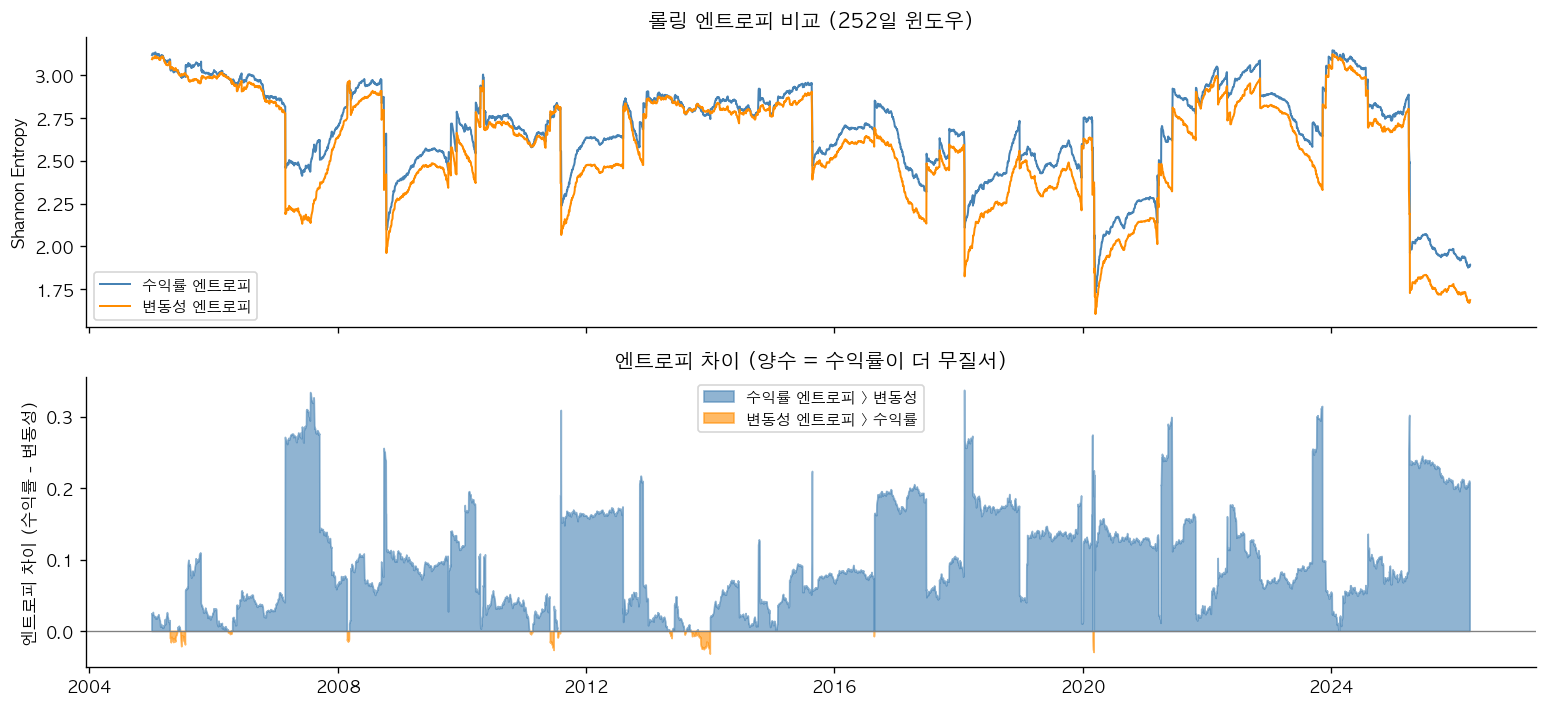

수익률 엔트로피 평균 : 2.6757
변동성 엔트로피 평균 : 2.5749
→ 전체 기간의 96.0% 구간에서 수익률이 변동성보다 더 무질서
   변동성이 상대적으로 더 많은 구조적 패턴을 내포한다.


In [12]:
def rolling_entropy(series, window=252, bins=30):
    ents = []
    for i in range(window, len(series)):
        chunk = series.iloc[i-window:i]
        counts, _ = np.histogram(chunk, bins=bins)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        ents.append(-np.sum(probs * np.log(probs)))
    return pd.Series(ents, index=series.index[window:])

window, bins_n = 252, 30
ent_ret_rolling = rolling_entropy(ret, window, bins_n)
ent_vol_rolling = rolling_entropy(vol, window, bins_n)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(ent_ret_rolling.index, ent_ret_rolling.values,
             lw=1.2, color='steelblue', label='수익률 엔트로피')
axes[0].plot(ent_vol_rolling.index, ent_vol_rolling.values,
             lw=1.2, color='darkorange', label='변동성 엔트로피')
axes[0].set_ylabel('Shannon Entropy')
axes[0].set_title('롤링 엔트로피 비교 (252일 윈도우)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

diff = ent_ret_rolling - ent_vol_rolling
axes[1].fill_between(diff.index, diff.values, 0,
                     where=(diff.values > 0), color='steelblue', alpha=0.6,
                     label='수익률 엔트로피 > 변동성')
axes[1].fill_between(diff.index, diff.values, 0,
                     where=(diff.values < 0), color='darkorange', alpha=0.6,
                     label='변동성 엔트로피 > 수익률')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('엔트로피 차이 (수익률 - 변동성)')
axes[1].set_title('엔트로피 차이 (양수 = 수익률이 더 무질서)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

pct = (diff > 0).mean() * 100
print(f'수익률 엔트로피 평균 : {ent_ret_rolling.mean():.4f}')
print(f'변동성 엔트로피 평균 : {ent_vol_rolling.mean():.4f}')
print(f'→ 전체 기간의 {pct:.1f}% 구간에서 수익률이 변동성보다 더 무질서')
print(f'   변동성이 상대적으로 더 많은 구조적 패턴을 내포한다.')

**📌 해석**
- 대부분의 기간에서 **수익률 엔트로피 > 변동성 엔트로피** (파란 영역이 압도적).
- 수익률은 변동성보다 더 무질서하다 → **변동성이 상대적으로 더 예측 가능한 타깃**.
- 특히 금융위기, 코로나 구간에서 차이가 크게 벌어진다 → 위기 국면에서 변동성 구조가 더 뚜렷.
- → 수익률 방향보다 변동성 크기를 예측하는 것이 통계적으로 더 실현 가능하다.


---
## ✅ Part 2 소결 : 변동성은 예측 가능한 구조를 가진다

| 분석 | 결과 | 해석 |
|------|------|------|
| 변동성 산점도 | 양의 기울기, R² > 0 | 어제 변동성이 오늘을 설명 |
| ARCH 검정 | p ≈ 0 → 강하게 기각 | 변동성 군집 통계적 확인 |
| ACF (\|r\|, r²) | lag 60까지 유의한 자기상관 | 장기 기억 구조 존재 |
| Chow Test | p < 0.05 → 기각 | 2008, 2020 국면 전환 확인 |
| 롤링 엔트로피 | 96% 구간에서 수익률 > 변동성 | 변동성이 더 구조적 |

> **결론 : 변동성은 예측 가능한 구조적 패턴을 가진다.**

---

## 🏁 최종 결론

| | 수익률 (r) | 변동성 (\|r\|) |
|--|-----------|--------------|
| 산점도 | R² ≈ 0, 패턴 없음 | 양의 기울기, 패턴 있음 |
| 자기상관 | 없음 | 강하고 지속적 |
| 구조적 변화 | CUSUM 안정 (신호 없음) | CUSUMSQ 이탈 (구조 있음) |
| 국면 전환 | Chow p > 0.05 (없음) | Chow p < 0.05 (있음) |
| 정보량 | 높은 엔트로피 (무질서) | 낮은 엔트로피 (구조적) |

> 수익률 방향성 예측은 효율적 시장 가설과 부합하게 **통계적으로 불가능에 가깝다**.  
> 반면 변동성은 군집, 자기상관, 국면 전환 등 **예측 가능한 구조**가 다각도로 확인된다.  
> **따라서 본 연구는 수익률이 아닌 변동성 예측을 목적으로 모델을 설계한다.**